<a href="https://colab.research.google.com/github/evucelic/Diplomski-Projekt/blob/hmm-vae/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(
    "/content/100_Portfolios_10x10_Daily_valueweighted.csv",
    parse_dates=True,
    low_memory=False
)
data = data.set_index("Date")
data.head()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
19260701,-99.99,0.00,-99.99,1.59,-3.08,4.64,2.57,3.81,-0.52,-0.84,...,0.00,1.10,-0.15,-0.03,0.52,0.48,-0.43,-0.08,0.17,-99.99
19260702,-99.99,-0.27,-99.99,0.00,-0.97,-4.10,0.31,-0.47,2.74,-0.27,...,0.31,0.71,0.97,0.57,0.52,0.15,0.63,-0.04,0.34,-99.99
19260706,-99.99,1.01,-99.99,-4.69,2.35,-1.79,0.00,2.44,-5.18,-0.23,...,0.49,-0.19,0.89,0.31,-0.12,-0.18,-0.33,-0.40,-0.34,-99.99
19260707,-99.99,-1.67,-99.99,4.92,0.51,5.27,0.00,-0.74,-0.24,-0.02,...,-0.20,-0.01,0.66,0.38,0.03,0.25,-0.29,0.52,0.17,-99.99
19260708,-99.99,0.00,-99.99,1.56,-0.51,-1.06,0.00,4.90,0.45,0.26,...,0.56,-0.12,0.35,0.55,-0.14,0.19,-0.12,0.54,0.51,-99.99


In [3]:
data= data.replace(-99.99, np.nan)
data = data.replace(-999, np.nan)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26110 entries, 19260701 to 20251031
Data columns (total 100 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SMALL LoBM  23562 non-null  float64
 1   ME1 BM2     23230 non-null  float64
 2   ME1 BM3     23208 non-null  float64
 3   ME1 BM4     24616 non-null  float64
 4   ME1 BM5     25171 non-null  float64
 5   ME1 BM6     25805 non-null  float64
 6   ME1 BM7     25813 non-null  float64
 7   ME1 BM8     26107 non-null  float64
 8   ME1 BM9     26110 non-null  float64
 9   SMALL HiBM  26110 non-null  float64
 10  ME2 BM1     23530 non-null  float64
 11  ME2 BM2     24323 non-null  float64
 12  ME2 BM3     25421 non-null  float64
 13  ME2 BM4     26102 non-null  float64
 14  ME2 BM5     25807 non-null  float64
 15  ME2 BM6     26110 non-null  float64
 16  ME2 BM7     26110 non-null  float64
 17  ME2 BM8     26110 non-null  float64
 18  ME2 BM9     26110 non-null  float64
 19  ME2 BM10    26110 n

In [5]:
data = data.fillna(0)
data = data / 100.0
data = data.astype(np.float32)
data.index = pd.to_datetime(data.index, format="%Y%m%d")

In [6]:
# print(data.min().min(), data.max().max())
# print(data.describe(percentiles=[0.001, 0.01, 0.99, 0.999]).T.sort_values("min").head(5))
# print(data.info())

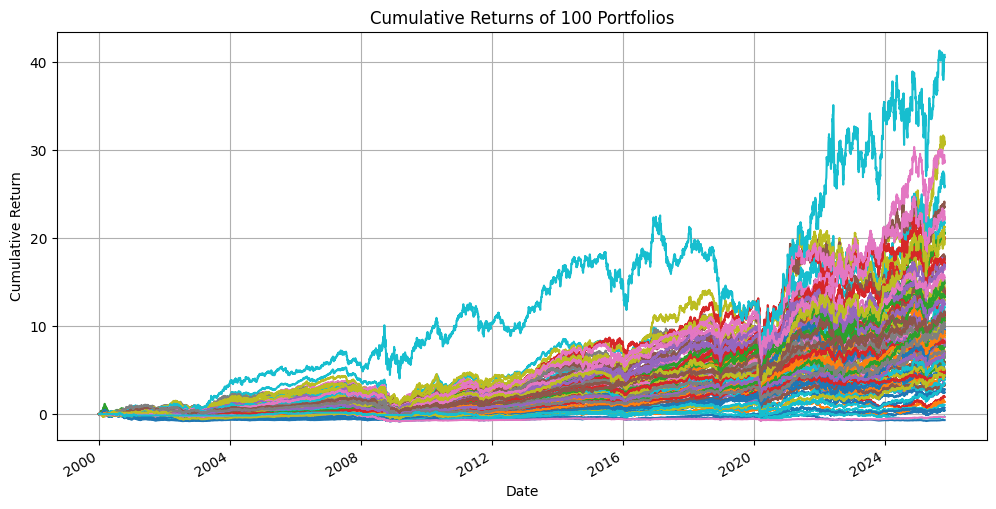

In [7]:
cum_returns = (1 + data.loc[data.index > "2000-01-01"]).cumprod() - 1
cum_returns.plot(figsize=(12, 6))
plt.title("Cumulative Returns of 100 Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid()
plt.legend().set_visible(False)
plt.show()

Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

In [8]:
from sklearn.model_selection import TimeSeriesSplit

max_years_lookback = 30

tscv_y = TimeSeriesSplit(n_splits=30, max_train_size=max_years_lookback*252, test_size=252)
tscv_q = TimeSeriesSplit(n_splits=20, max_train_size=max_years_lookback*252, test_size=63+50)
tscv_m = TimeSeriesSplit(n_splits=10, max_train_size=max_years_lookback*252, test_size=21)


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

![image](https://github.com/evucelic/Diplomski-Projekt/blob/hmm-vae/images/1-s2.0-S0020025525003160-gr001.jpg?raw=1)

In [10]:
# class MLP(nn.Module):
#     """
#     Learn VAR(1) dynamics: p(z_t | z_{t-1}).
#     """
#     def __init__(self, z_dim, hidden_dim):
#         super().__init__()
#         self.fc1 = nn.Linear(z_dim, hidden_dim)
#         self.fc_mu = nn.Linear(hidden_dim, z_dim)
#         self.fc_logvar = nn.Linear(hidden_dim, z_dim)

#     def forward(self, z_prev):
#         h = F.relu(self.fc1(z_prev))
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         return mu, logvar

In [11]:
class Encoder(nn.Module):
    def __init__(self, W, D, z_dim, hidden_dim=128):
        super().__init__()
        in_dim = W * D
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

    def forward(self, x):  # x: (B, W, D)
        h = F.relu(self.fc1(x.flatten(1)))
        return self.fc_mu(h), self.fc_logvar(h)


In [12]:
class DecoderGaussian(nn.Module):
    def __init__(self, D, z_dim, hidden_dim=128, min_logvar=-8.0, max_logvar=4.0):
        super().__init__()
        self.fc1 = nn.Linear(z_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, D) # output: single day, D portfolios
        self.fc_logvar = nn.Linear(hidden_dim, D)
        self.D = D
        self.min_logvar = min_logvar
        self.max_logvar = max_logvar

    def forward(self, z):  # z: (B, z_dim)
        h= F.relu(self.fc1(z))
        mu = self.fc_mu(h) # (B, D)
        logvar = self.fc_logvar(h) # (B, D)
        logvar = torch.clamp(logvar, self.min_logvar, self.max_logvar)
        return mu, logvar

In [13]:
class VAE(nn.Module):
    def __init__(self, W, D, z_dim, hidden_dim=128):
        super().__init__()
        self.encoder = Encoder(W, D, z_dim, hidden_dim)
        self.decoder = DecoderGaussian(D, z_dim, hidden_dim)
        self.z_dim = z_dim
        self.W = W
        self.D = D

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, z_prev=None):
        """
        Forward pass (no temporal prior, just standard normal).
        Args:
            x: (B, W, D) - W-day window
            z_prev: (B, z_dim) - ignored for now
        Returns:
            x_mu, x_logsigma: decoded single-day returns (B, D)
            z_mu_post, z_logvar_post: posterior q(z_t | x)
            z_mu_prior, z_logvar_prior: standard normal prior
            z: sampled latent (B, z_dim)
        """
        # Encode current window -> posterior q(z_t | x_{t-W:t})
        z_mu_post, z_logvar_post = self.encoder(x)
        z = self.reparameterize(z_mu_post, z_logvar_post)

        # Decode z_t -> single day return
        x_mu, x_logsigma = self.decoder(z)

        z_mu_prior = torch.zeros_like(z_mu_post)
        z_logvar_prior = torch.zeros_like(z_logvar_post)

        return x_mu, x_logsigma, z_mu_post, z_logvar_post, z_mu_prior, z_logvar_prior, z


In [14]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
def kl_divergence(mu_post, logvar_post, mu_prior, logvar_prior):
    """
    KL( N(mu_post, exp(logvar_post)) || N(mu_prior, exp(logvar_prior)) )
    """
    # Clamp to prevent overflow/underflow
    logvar_post = torch.clamp(logvar_post, -10, 10)
    logvar_prior = torch.clamp(logvar_prior, -10, 10)

    # More stable: exp(logvar_post - logvar_prior) instead of exp(logvar_post) / exp(logvar_prior)
    kl = 0.5 * (
        logvar_prior - logvar_post
        + torch.exp(logvar_post - logvar_prior)
        + ((mu_post - mu_prior) ** 2) * torch.exp(-logvar_prior)
        - 1.0
    )
    return kl.sum(dim=-1)



# TODO https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/
def loss_fn(x_mu, x_logsigma, x_target,
            z_mu_post, z_logvar_post,
            z_mu_prior, z_logvar_prior,
            beta=1.0):
    x_logsigma = torch.clamp(x_logsigma, -10, 5)

    # Reconstruction loss
    recon = 0.5 * (
        x_logsigma
        + ((x_target - x_mu) ** 2) * torch.exp(-x_logsigma)
    ).sum(dim=1).mean()

    # KL divergence
    kl = kl_divergence(
        z_mu_post, z_logvar_post,
        z_mu_prior, z_logvar_prior
    ).mean()

    total_loss = recon + beta * kl
    return total_loss, recon, kl

In [15]:
class Dataset(Dataset):
    def __init__(self, returns, window_size):
        super().__init__()
        self.returns = returns
        self.window_size = window_size

    def __len__(self):
        return len(self.returns) - self.window_size

    def __getitem__(self, idx):
        x_window = torch.FloatTensor(self.returns[idx:idx+self.window_size])  # (W, D)
        x_target = torch.FloatTensor(self.returns[idx+self.window_size])      # (D,)
        return x_window, x_target

In [16]:
def train_vae(model, returns_train, W=50, epochs=20, lr=1e-3, device='cuda'):
    """Train VAE (no temporal prior)."""
    model = model.to(device).train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr* 128/256)
    dataloader = DataLoader(Dataset(returns_train, W), batch_size=128, shuffle=False)

    print(f"Training: {len(dataloader)} samples, {epochs} epochs, device={device}\n")

    for epoch in range(epochs):
        total_loss = 0

        for x_window, x_target in dataloader:
            x_window, x_target = x_window.to(device), x_target.to(device)

            # Forward
            optimizer.zero_grad()
            x_mu, x_logsigma, z_mu_post, z_logvar_post, z_mu_prior, z_logvar_prior, z = \
                model(x_window, None)

            loss, recon, kl = loss_fn(x_mu, x_logsigma, x_target,
                                      z_mu_post, z_logvar_post,
                                      z_mu_prior, z_logvar_prior, beta=1.0)

            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1:2d}/{epochs}: Loss={avg_loss:.2f}")

    print("\nDone!")
    return model


@torch.no_grad()
def extract_latents(model, data, W=50, device='cuda', batch_size=128):
    model.eval()
    dataloader = DataLoader(Dataset(data, W), batch_size=batch_size, shuffle=False)

    latents = []
    for x_window, _ in dataloader:
        x_window = x_window.to(device)
        _, _, z_mu_post, _, _, _, _ = model(x_window, None)
        latents.append(z_mu_post.cpu().numpy())

    return np.concatenate(latents, axis=0)  # Shape: (N, z_dim)


In [17]:
from sklearn.preprocessing import StandardScaler
results = {'models': [], 'train_latents': [], 'test_latents': [],
           'train_idx': [], 'test_idx': []}

for fold, (train_idx, test_idx) in enumerate(tscv_q.split(data.values)):
    print(f"\n{'='*60}")
    print(f"Fold {fold+1}/20 | Train: {len(train_idx)} days | Test: {len(test_idx)} days")
    print(f"{'='*60}")
    train_data = data.values[train_idx]
    test_data = data.values[test_idx]

    scaler = StandardScaler()
    train_data = scaler.fit_transform(train_data)
    test_data = scaler.transform(test_data)

    vae_model = VAE(W=50, D=100, z_dim=10, hidden_dim=128)
    vae_model = train_vae(vae_model, train_data, W=50, epochs=100, lr=1e-3, device='cuda')

    train_latents = extract_latents(vae_model, train_data, W=50, device='cuda')
    test_latents = extract_latents(vae_model, test_data, W=50, device='cuda')

    results['models'].append(vae_model)
    results['train_latents'].append(np.array(train_latents))
    results['test_latents'].append(np.array(test_latents))
    results['train_idx'].append(train_idx[50:])  # Adjust for window size
    results['test_idx'].append(test_idx[50:])    # Adjust for window size


Fold 1/20 | Train: 7560 days | Test: 113 days
Training: 59 samples, 100 epochs, device=cuda

Epoch  1/100: Loss=61.16
Epoch  2/100: Loss=75.90
Epoch  3/100: Loss=77.36
Epoch  4/100: Loss=72.48
Epoch  5/100: Loss=65.45
Epoch  6/100: Loss=62.57
Epoch  7/100: Loss=54.07
Epoch  8/100: Loss=46.12
Epoch  9/100: Loss=39.23
Epoch 10/100: Loss=33.14
Epoch 11/100: Loss=28.27
Epoch 12/100: Loss=24.54
Epoch 13/100: Loss=20.42
Epoch 14/100: Loss=15.86
Epoch 15/100: Loss=13.96
Epoch 16/100: Loss=14.92
Epoch 17/100: Loss=14.21
Epoch 18/100: Loss=12.41
Epoch 19/100: Loss=12.36
Epoch 20/100: Loss=20.96
Epoch 21/100: Loss=22.45
Epoch 22/100: Loss=14.30
Epoch 23/100: Loss=12.22
Epoch 24/100: Loss=7.33
Epoch 25/100: Loss=5.71
Epoch 26/100: Loss=8.67
Epoch 27/100: Loss=6.35
Epoch 28/100: Loss=4.29
Epoch 29/100: Loss=2.55
Epoch 30/100: Loss=7.54
Epoch 31/100: Loss=9.26
Epoch 32/100: Loss=3.09
Epoch 33/100: Loss=1.46
Epoch 34/100: Loss=3.88
Epoch 35/100: Loss=4.93
Epoch 36/100: Loss=4.90
Epoch 37/100: Loss=

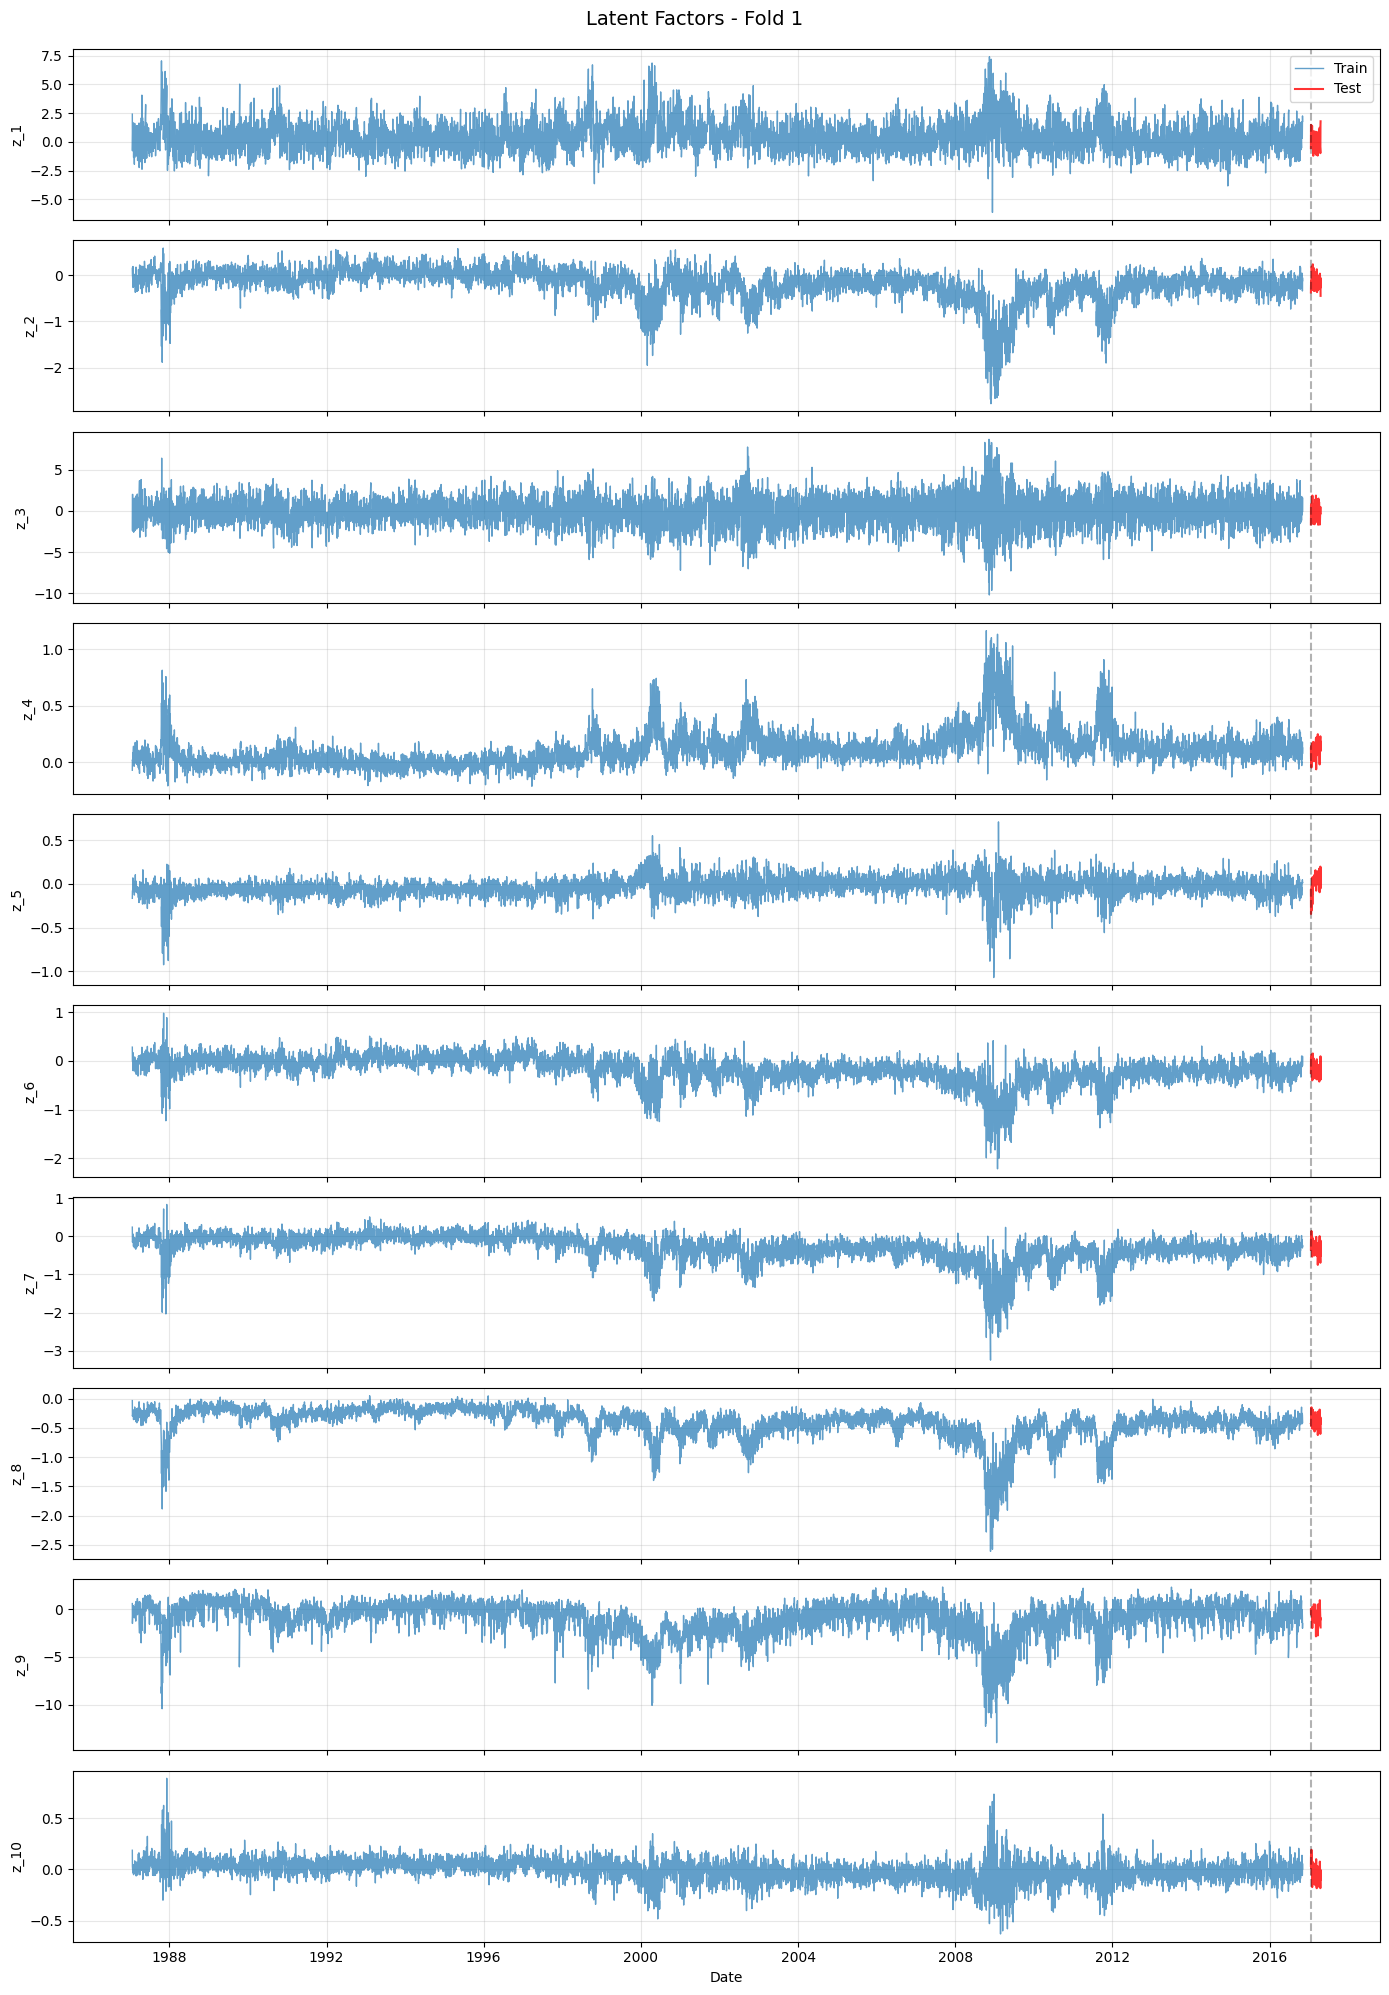

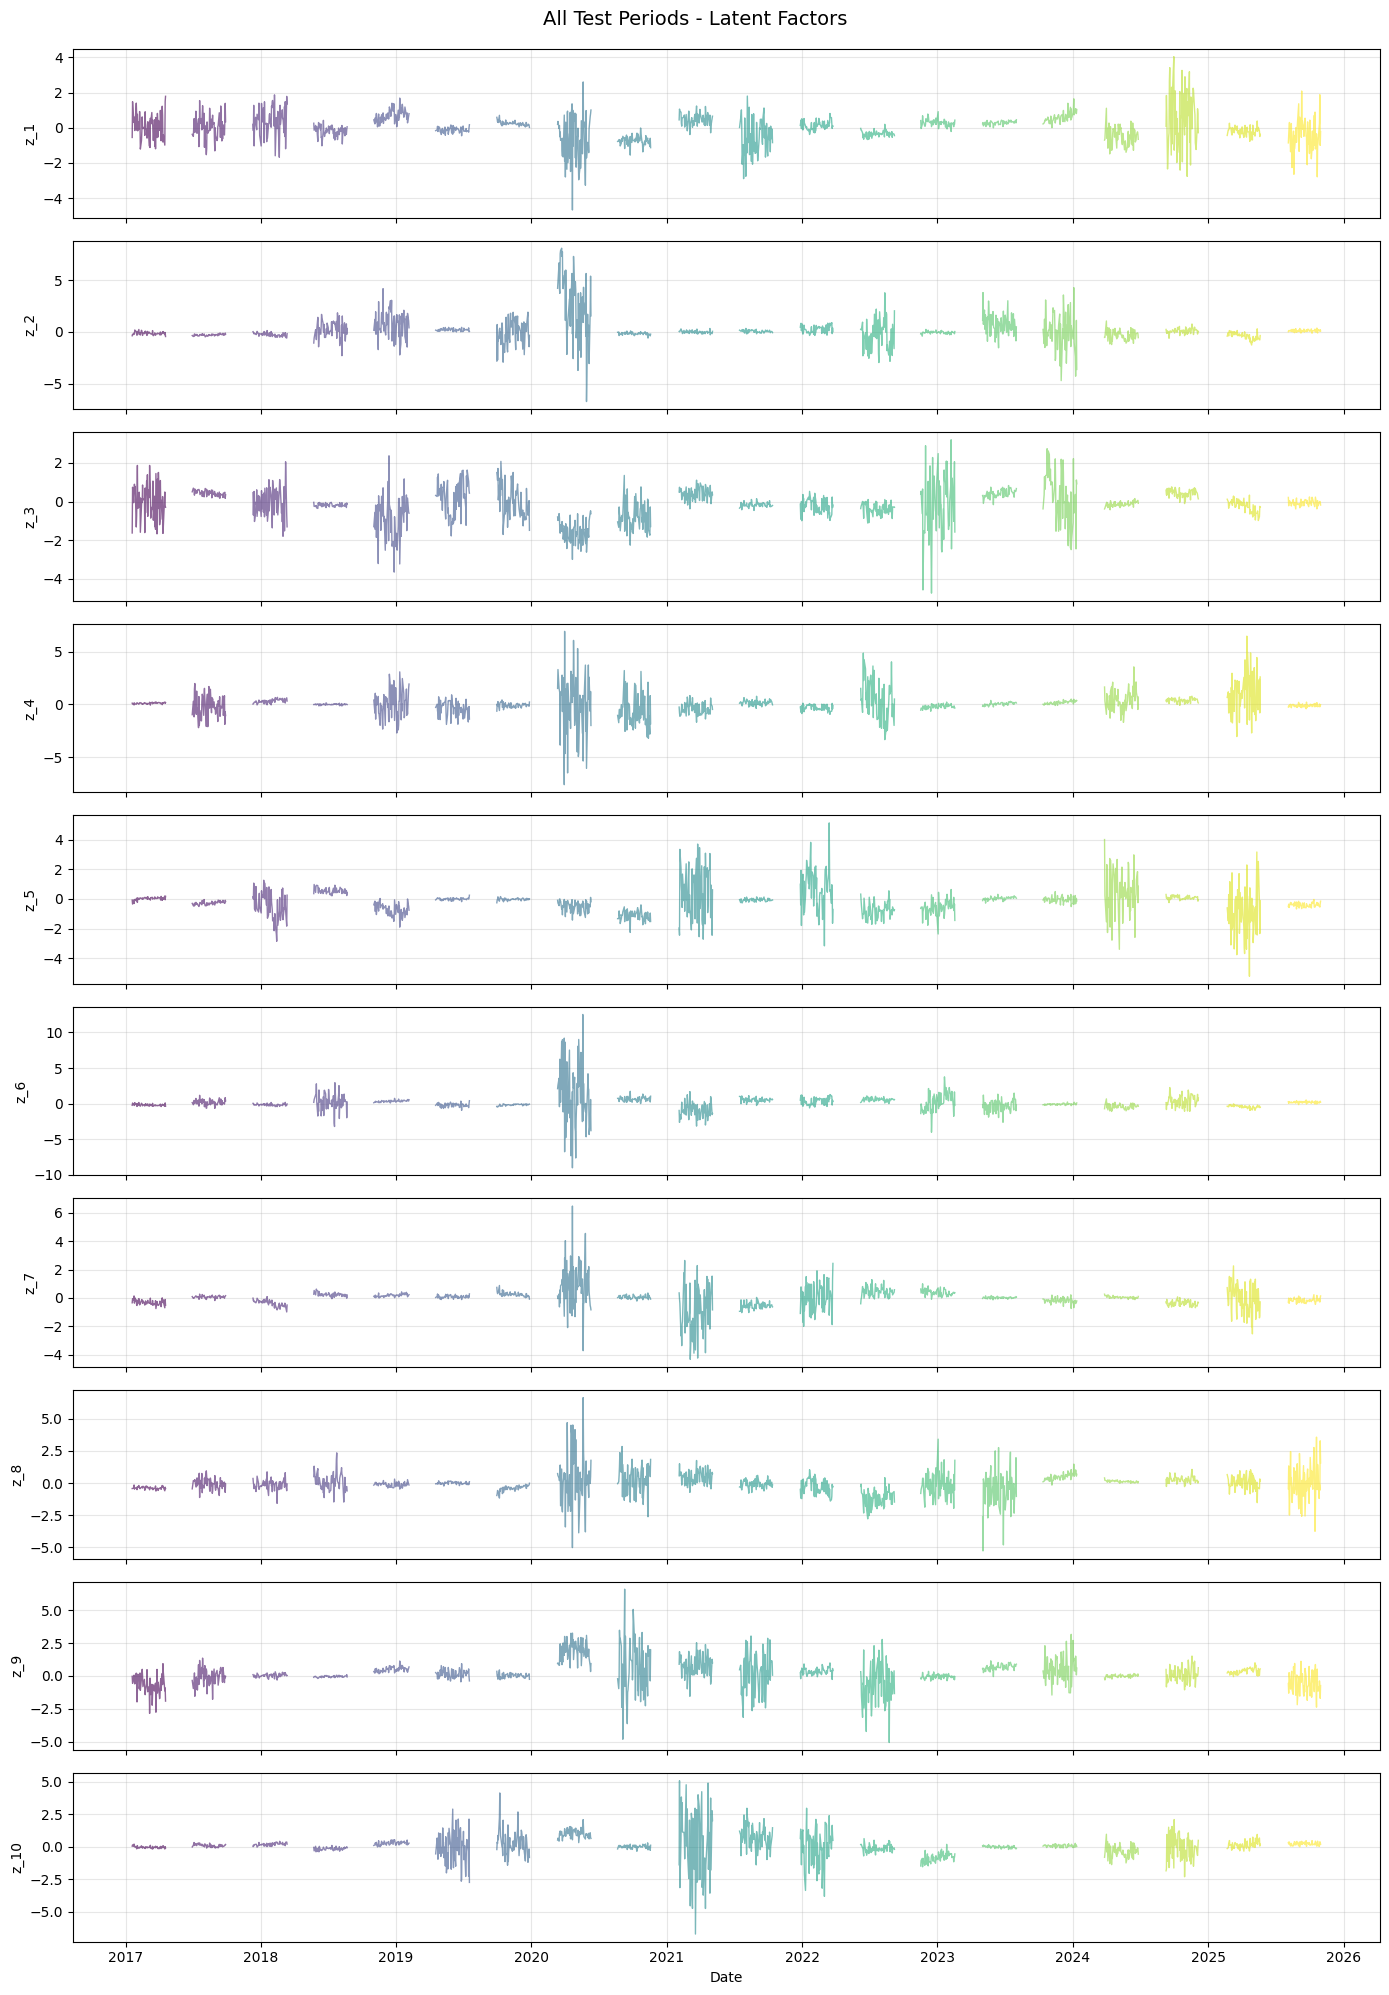


Latent Statistics Summary

Train latents: (150200, 10)
Test latents:  (1260, 10)

Train:
  Mean: [ 0.06 -0.03 -0.02  0.05 -0.13  0.04 -0.05  0.    0.07 -0.  ]
  Std:  [0.96 1.03 1.06 1.05 0.97 0.97 0.66 1.   1.1  1.  ]

Test:
  Mean: [ 0.01  0.13 -0.14  0.04 -0.18  0.09 -0.01 -0.06  0.21  0.06]
  Std:  [0.78 1.19 0.85 1.12 0.9  1.25 0.73 0.91 0.99 0.93]

Health checks:
  ✓ Mean near zero
  ✓ Std reasonable
  ✓ No NaN values



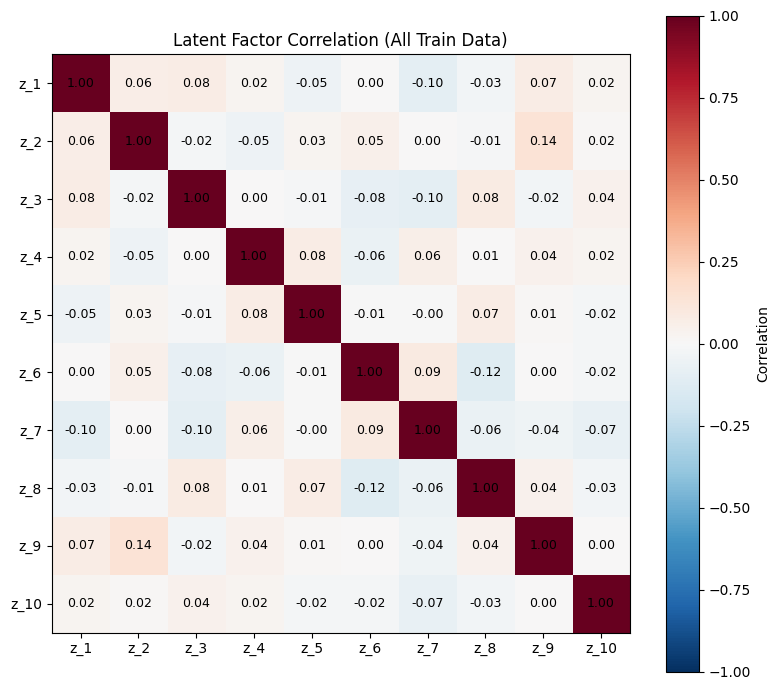

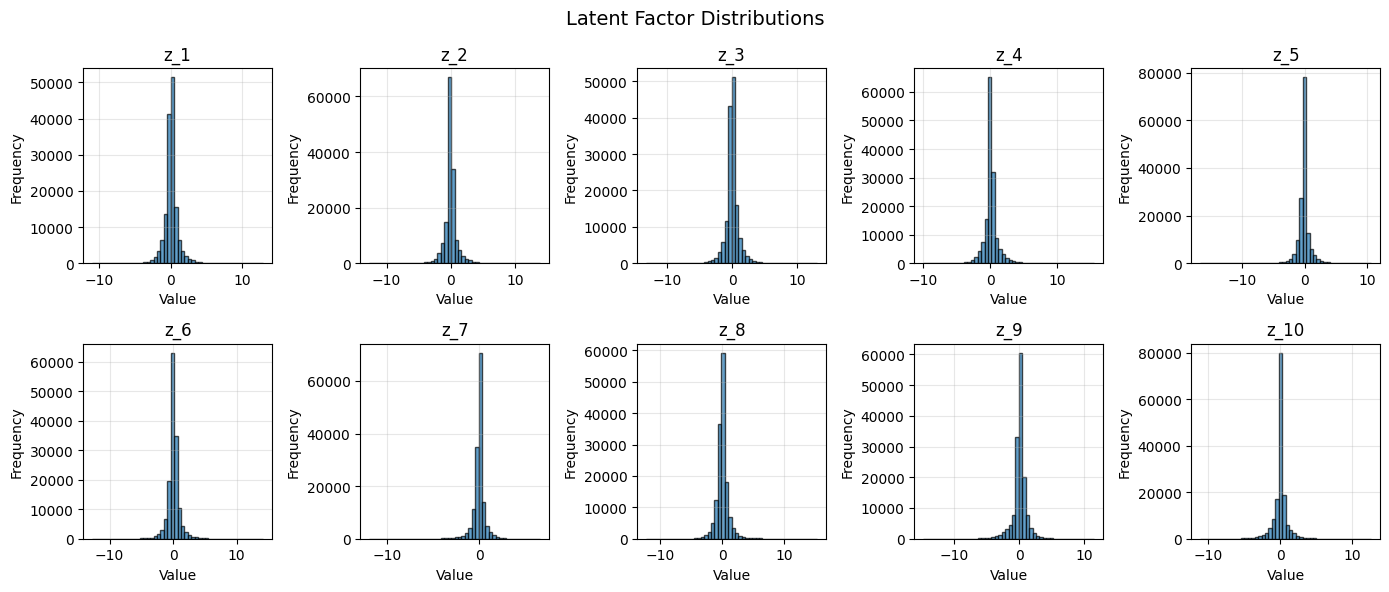

In [18]:
def plot_fold(results, data, fold=0):
    """Plot latents for one fold."""
    train_latents = results['train_latents'][fold]
    test_latents = results['test_latents'][fold]
    train_idx = results['train_idx'][fold]
    test_idx = results['test_idx'][fold]

    z_dim = train_latents.shape[1]

    fig, axes = plt.subplots(z_dim, 1, figsize=(14, 2*z_dim), sharex=True)
    if z_dim == 1:
        axes = [axes]

    for i in range(z_dim):
        axes[i].plot(data.index[train_idx], train_latents[:, i],
                    label='Train', alpha=0.7, linewidth=1)
        axes[i].plot(data.index[test_idx], test_latents[:, i],
                    label='Test', color='red', alpha=0.8, linewidth=1.5)
        axes[i].axvline(data.index[test_idx[0]], color='black',
                       linestyle='--', alpha=0.3)
        axes[i].set_ylabel(f'z_{i+1}')
        axes[i].grid(alpha=0.3)
        if i == 0:
            axes[i].legend()

    axes[-1].set_xlabel('Date')
    plt.suptitle(f'Latent Factors - Fold {fold+1}', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

plot_fold(results, data, fold=0)


# 2. Visualize all test periods together
def plot_all_test_folds(results, data):
    """Plot test latents from all folds."""
    z_dim = results['test_latents'][0].shape[1]
    n_folds = len(results['test_latents'])

    fig, axes = plt.subplots(z_dim, 1, figsize=(14, 2*z_dim), sharex=True)
    if z_dim == 1:
        axes = [axes]

    colors = plt.cm.viridis(np.linspace(0, 1, n_folds))

    for i in range(z_dim):
        for fold in range(n_folds):
            test_latents = results['test_latents'][fold]
            test_idx = results['test_idx'][fold]
            axes[i].plot(data.index[test_idx], test_latents[:, i],
                        alpha=0.6, linewidth=1, color=colors[fold])

        axes[i].set_ylabel(f'z_{i+1}')
        axes[i].grid(alpha=0.3)

    axes[-1].set_xlabel('Date')
    plt.suptitle('All Test Periods - Latent Factors', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

plot_all_test_folds(results, data)


# 3. Statistics summary
def summarize_latents(results):
    """Print statistics across all folds."""
    print(f"\n{'='*60}")
    print("Latent Statistics Summary")
    print(f"{'='*60}")

    # Concatenate all train latents
    all_train = np.vstack(results['train_latents'])
    all_test = np.vstack(results['test_latents'])

    print(f"\nTrain latents: {all_train.shape}")
    print(f"Test latents:  {all_test.shape}")

    print(f"\nTrain:")
    print(f"  Mean: {all_train.mean(axis=0).round(2)}")
    print(f"  Std:  {all_train.std(axis=0).round(2)}")

    print(f"\nTest:")
    print(f"  Mean: {all_test.mean(axis=0).round(2)}")
    print(f"  Std:  {all_test.std(axis=0).round(2)}")

    # Check for issues
    print(f"\nHealth checks:")
    if np.abs(all_train.mean()) < 2:
        print("  ✓ Mean near zero")
    else:
        print("  ⚠️ Mean drift detected")

    if all_train.std(axis=0).max() < 10:
        print("  ✓ Std reasonable")
    else:
        print("  ⚠️ Large variance detected")

    if not np.any(np.isnan(all_train)):
        print("  ✓ No NaN values")
    else:
        print("  ⚠️ NaN values present")

    print(f"{'='*60}\n")

summarize_latents(results)


# 4. Correlation heatmap (train data)
def plot_correlation(results):
    """Plot correlation between latent factors."""
    all_train = np.vstack(results['train_latents'])
    corr = np.corrcoef(all_train.T)
    z_dim = corr.shape[0]

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

    ax.set_xticks(range(z_dim))
    ax.set_yticks(range(z_dim))
    ax.set_xticklabels([f'z_{i+1}' for i in range(z_dim)])
    ax.set_yticklabels([f'z_{i+1}' for i in range(z_dim)])

    # Add correlation values
    for i in range(z_dim):
        for j in range(z_dim):
            text = ax.text(j, i, f'{corr[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=9)

    plt.colorbar(im, ax=ax, label='Correlation')
    plt.title('Latent Factor Correlation (All Train Data)')
    plt.tight_layout()
    plt.show()

plot_correlation(results)


# 5. Distribution of latents
def plot_distributions(results):
    """Plot distributions of each latent factor."""
    all_train = np.vstack(results['train_latents'])
    z_dim = all_train.shape[1]

    fig, axes = plt.subplots(2, (z_dim+1)//2, figsize=(14, 6))
    axes = axes.flatten()

    for i in range(z_dim):
        axes[i].hist(all_train[:, i], bins=50, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'z_{i+1}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)

    # Hide unused subplots
    for i in range(z_dim, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Latent Factor Distributions', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_distributions(results)


In [19]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.1 MB/s eta 0:00:00


In [20]:
from hmmlearn.hmm import GaussianHMM
from sklearn.utils import check_random_state
from collections import defaultdict

rs = check_random_state(42)

In [21]:
def evaluate_hmm(latents, rs, ns, loop):
    """
    Evaluate HMM models with different numbers of states to find the ones with the best LL, AIC and BIC scores.
    Parameters:
        latents (np.ndarray): Latent representations with shape (N, z_dim).
        rs (int): Random state for reproducibility.
        ns (list): List of numbers of states to evaluate.
        loop (int): Number of iterations for each number of states.
    Returns:
        tuple: A tuple containing lists of AIC, BIC, LL scores, convergence status, iterations,
               best models, and all models for each number of states.
    """
    aic = []
    bic = []
    lls = []
    convergence_status = []
    iterations = []
    models = defaultdict(list)
    # saved in this format: {number_of_states: [(model, LL), ...]}
    best_models = defaultdict()

    X = latents
    lengths = [len(X)]

    for n in ns:
        best_ll = None
        best_model = None
        for _ in range(loop):
            h = GaussianHMM(
                n,
                n_iter=2000,
                tol=1e-6,
                random_state=rs,
                covariance_type="full",
                verbose=False,
            )
            h.fit(X, lengths)
            score = h.score(X, lengths)
            models[n].append((h, score))
            if not best_ll or best_ll < score:
                best_ll = score
                best_model = h

        best_models[n] = best_model
        aic.append(best_model.aic(X, lengths))
        bic.append(best_model.bic(X, lengths))
        lls.append(best_model.score(X, lengths))
        convergence_status.append(best_model.monitor_.converged)
        iterations.append(best_model.monitor_.iter)

    # Log to make sure the results converge
    print("Convergence Status: ", convergence_status)
    print("Iterations: ", iterations)
    return aic, bic, lls, convergence_status, iterations, best_models, models

In [22]:
def plot_selection(ns, aic, bic, lls):
    """
    Plot AIC, BIC, and LL scores for model selection.
    Parameters:
        ns (list): List of numbers of states.
        aic (list): List of AIC scores.
        bic (list): List of BIC scores.
        lls (list): List of log-likelihood scores.
    Returns:
        None
    """
    fig, ax = plt.subplots()
    ax.plot(ns, aic, label="AIC", color="blue", marker="o")
    ax.plot(ns, bic, label="BIC", color="green", marker="o")
    ax2 = ax.twinx()
    ax2.plot(ns, lls, label="LL", color="orange", marker="o")
    ax.legend(handles=ax.lines + ax2.lines)
    ax.set_title("Evaluacija HMM koristeći AIC/BIC i LL")
    ax.set_ylabel("Informacijski kriterij (niže je bolje)")
    ax2.set_ylabel("Log izglednost (više je bolje)")
    ax.set_xlabel("Broj skrivenih stanja")
    fig.tight_layout()
    # plt.savefig("figures/hmm_model_selection.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

In [23]:
def plot_ll_histograms(models):
    """
    Plot histograms of log-likelihood scores for each number of states.
    Parameters:
        models (dict): Dictionary containing models and their log-likelihood scores.
    Returns:
        None
    """
    ns = sorted(models.keys())
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes = axes.ravel()

    for idx, n_components in enumerate(ns):
        component_scores = [score for (_, score) in models[n_components]]

        axes[idx].hist(
            component_scores, bins=25, edgecolor="k", alpha=0.65, density=True
        )

        axes[idx].set_title(
            f"{n_components} skrivena stanja\n(n={len(component_scores)})", pad=12
        )
        axes[idx].set_xlabel("Log izglednost", labelpad=8)
        axes[idx].set_ylabel("Gustoća", labelpad=8)
        axes[idx].grid(True, linestyle="--", alpha=0.6)

        mean_ll = np.mean(component_scores)
        axes[idx].axvline(
            mean_ll,
            color="r",
            linestyle="--",
            linewidth=1.5,
            label=f"Projsek: {mean_ll:.1f}",
        )
        axes[idx].legend()

    plt.tight_layout(pad=2.0)
    # plt.savefig("figures/hmm_log_likelihood_histograms.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

In [24]:
%%capture cap

hmm_results = []

aic, bic, lls, conv, iters, best_models, all_models = evaluate_hmm(
    latents=results['train_latents'][-1],
    rs=rs,
    ns=[2, 3, 4, 5, 6, 7],
    loop=10
)

best_n = [2, 3, 4, 5, 6, 7][np.argmin(bic)]
best_hmm = best_models[best_n]

hmm_results.append({
    'fold': fold,
    'n_states': best_n,
    'hmm': best_hmm,
    'train_regimes': best_hmm.predict(results['train_latents'][fold]),
    'test_regimes': best_hmm.predict(results['test_latents'][fold]),
    'aic': aic,
    'bic': bic,
    'lls': lls,
    'all_models': all_models
})


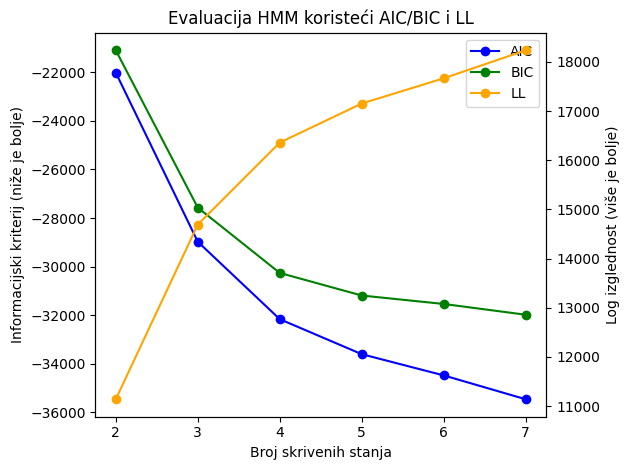

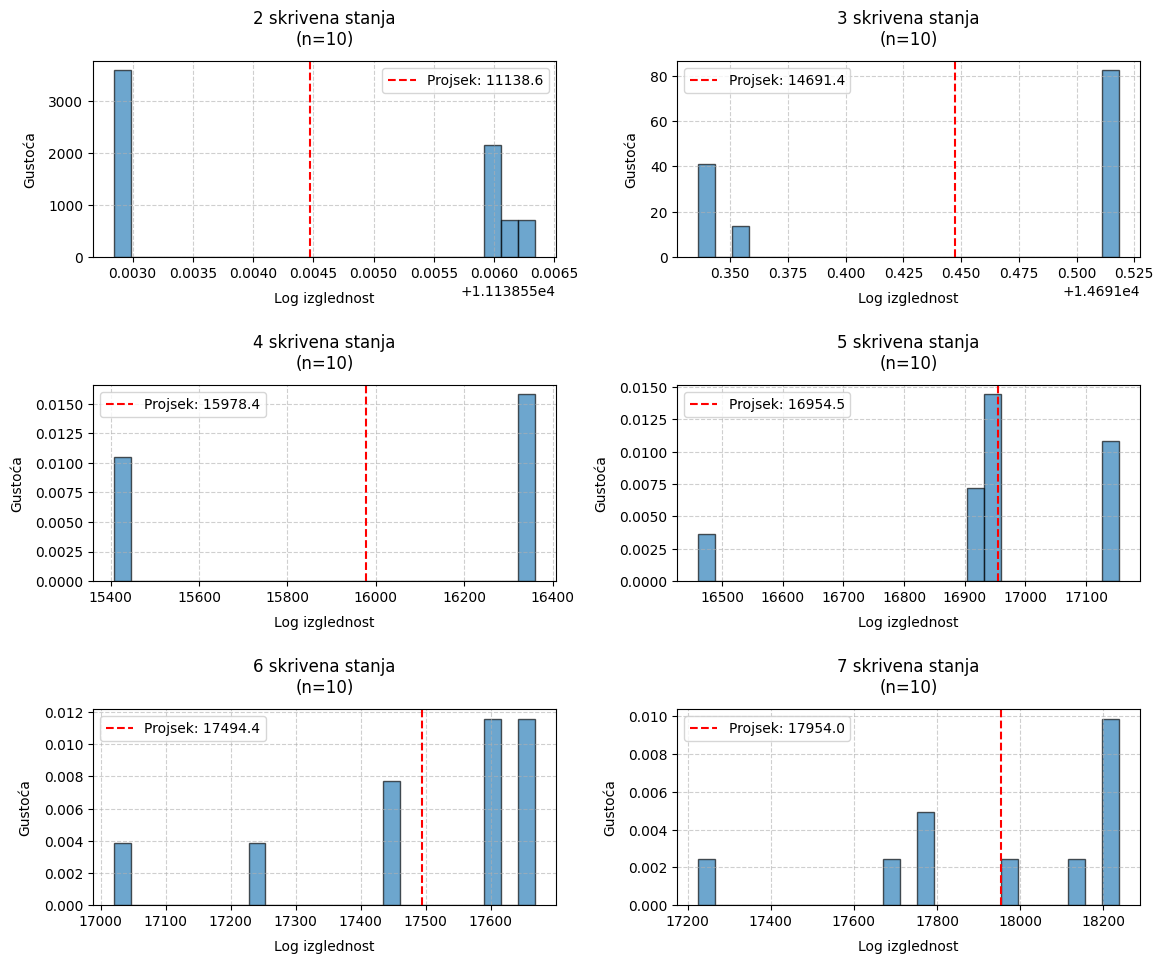

In [25]:
fold_idx = 2

plot_selection(
    ns=[2, 3, 4, 5, 6, 7],
    aic=hmm_results[fold_idx]['aic'],
    bic=hmm_results[fold_idx]['bic'],
    lls=hmm_results[fold_idx]['lls']
)

plot_ll_histograms(models=hmm_results[fold_idx]['all_models'])

In [26]:
fred_recessions = pd.read_csv("/content/fred_recession_cycles.csv")
fred_recessions["Peak"] = pd.to_datetime(fred_recessions["Peak"], format="%Y-%m-%d")
fred_recessions["Trough"] = pd.to_datetime(fred_recessions["Trough"], format="%Y-%m-%d")

In [27]:
def plot_single_ax(
    state_probs,
    time_index,
    n_regimes,
    fred_recessions=None,
    title="Estimated Regime Probabilities",
    ax=None,
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))

    # Dynamic color selection
    cmap_name = 'tab10' if n_regimes <= 10 else 'tab20' if n_regimes <= 20 else 'hsv'
    colors = plt.cm.get_cmap(cmap_name, n_regimes)
    line_styles = ["-", "--", ":", "-."]

    for j in range(n_regimes):
        sns.lineplot(
            x=time_index,
            y=state_probs[:, j],
            linestyle=line_styles[j % len(line_styles)],
            color=colors(j),
            linewidth=1.1,
            label=f"Režim {j+1}",
            ax=ax,
        )

    ax.set_ylim(-0.05, 1.19)
    ax.set_ylabel("Vjerojatnost", fontsize=10)
    ax.set_xlim(time_index[0], time_index[-1])
    ax.axhline(y=0, color="black", linestyle="-", alpha=0.2)
    ax.axhline(y=1, color="black", linestyle="-", alpha=0.2)

    if fred_recessions is not None:
        for _, row in fred_recessions.iterrows():
            ax.axvspan(row["Peak"], row["Trough"], color="gray", alpha=0.25, zorder=0)

    ax.legend(loc="upper right", ncol=min(n_regimes, 4), frameon=True, fontsize="small")
    ax.set_title(title, fontsize=11)
    sns.despine(ax=ax)

    return ax


def plot_regime_switches(model_parameters_df, state_probs_list, fred_recessions, n_regimes_list=None):
    import matplotlib.pyplot as plt
    import pandas as pd

    if n_regimes_list is None:
        n_regimes_list = [2, 3, 4]

    n_models = len(state_probs_list)
    fig, axes = plt.subplots(n_models, 1, figsize=(10, n_models * 2.67), sharex=True)
    if n_models == 1:
        axes = [axes]

    regime_text = ", ".join([f"({chr(97 + i)}) {n}" for i, n in enumerate(n_regimes_list)])
    fig.text(0.5, 0.95, f"Vjerojatnosti promjene režima za {regime_text} skrivena stanja.", ha="center", fontsize=11)

    year_ticks = pd.date_range(start=model_parameters_df.index[0], end=model_parameters_df.index[-1], freq="5YS")

    for i, (ax, prob, n_regime) in enumerate(zip(axes, state_probs_list, n_regimes_list)):
        plot_single_ax(prob, model_parameters_df.index, n_regime, fred_recessions, f"({chr(97 + i)})", ax)
        ax.set_xticks(year_ticks)
        ax.set_xticklabels([f"{date.year}" for date in year_ticks])
        ax.set_xlabel("Godina")
        ax.tick_params(axis="x", labelbottom=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0.3)
    plt.show()


/tmp/ipython-input-2200488050.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, n_regimes)
/tmp/ipython-input-2200488050.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, n_regimes)
/tmp/ipython-input-2200488050.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, n_regimes)
/tmp/ipython-input-2200488050.py:18: MatplotlibDeprecationWarning: The get_c

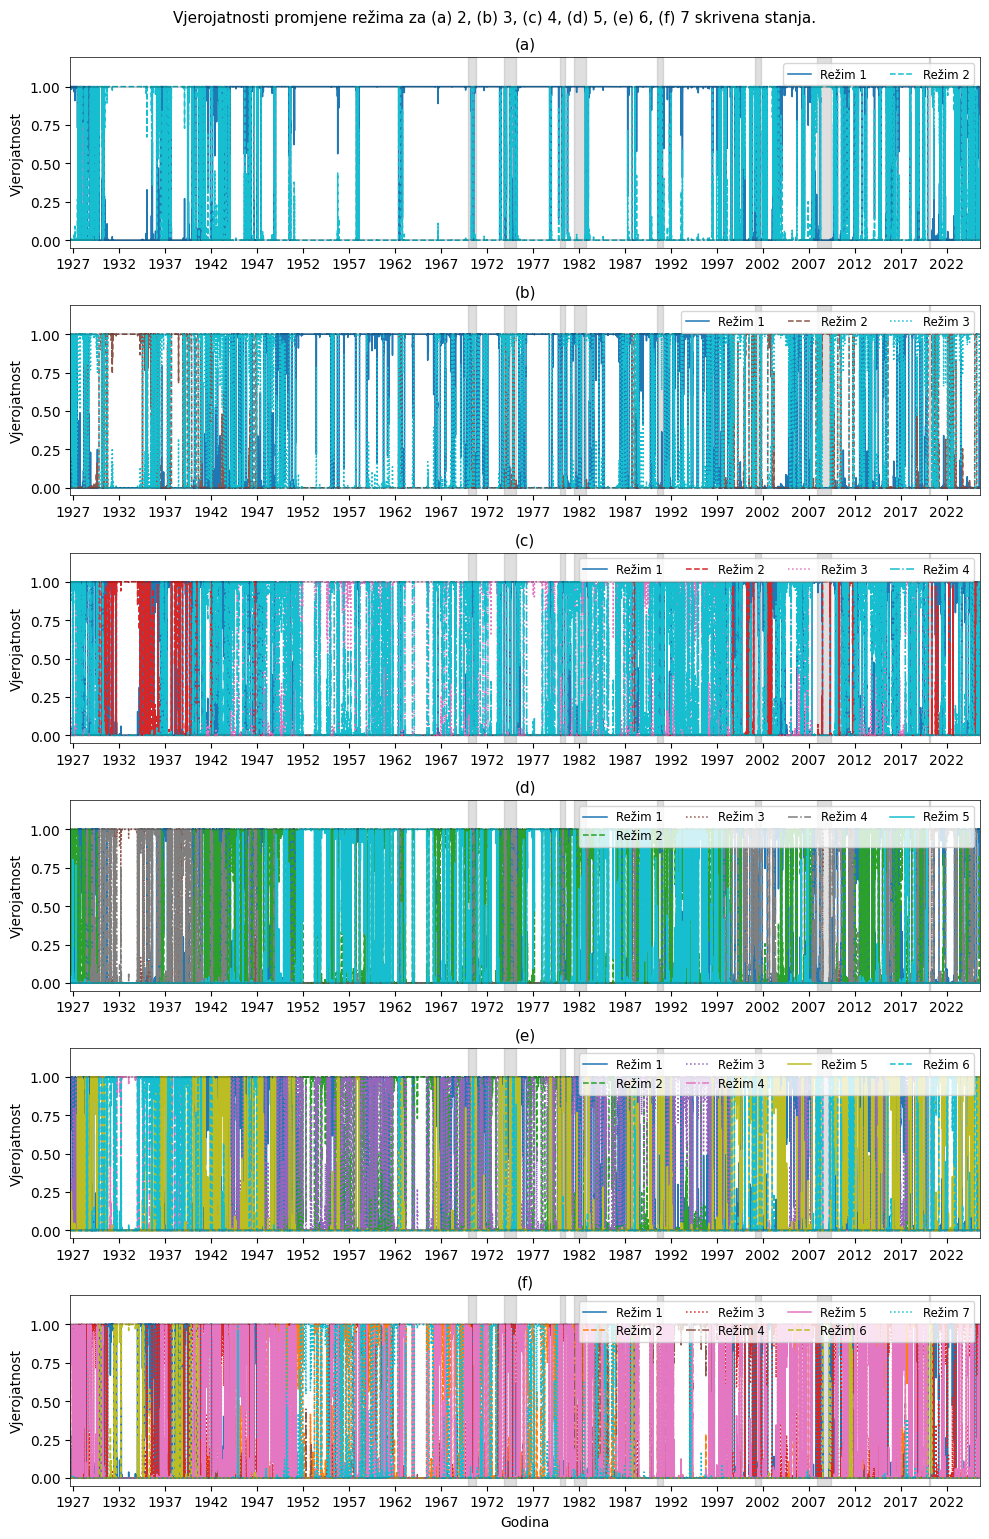

In [28]:
from sklearn.preprocessing import StandardScaler
import numpy as np

fold_idx = 2
vae_model = results['models'][fold_idx]

# Split first
train_size = int(0.8 * len(data))
train_data = data.values[:train_size]
test_data = data.values[train_size:]

# Scale separately
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Extract latents separately
train_latents = extract_latents(vae_model, train_data_scaled, W=50, device='cuda')
test_latents = extract_latents(vae_model, test_data_scaled, W=50, device='cuda')

# Generate state probabilities for all models
ns = [2, 3, 4, 5, 6, 7]
state_probs_list = []

for n in ns:
    model = best_models[n]
    model.fit(train_latents)
    train_probs = model.predict_proba(train_latents)
    test_probs = model.predict_proba(test_latents)
    full_probs = np.vstack([train_probs, test_probs])
    state_probs_list.append(full_probs)

# Calculate total samples after windowing
total_latent_samples = len(train_latents) + len(test_latents)

# Use the correct index slice
plot_regime_switches(
    data.iloc[50:50+total_latent_samples],  # Adjust for both windowing and actual length
    state_probs_list,
    fred_recessions,
    n_regimes_list=ns
)


In [29]:
def plot_single_ax_discrete(
    state_assignments,
    time_index,
    n_regimes,
    fred_recessions=None,
    title="Estimated Regime Assignments",
    ax=None,
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))

    # Dynamic color selection
    cmap_name = 'tab10' if n_regimes <= 10 else 'tab20' if n_regimes <= 20 else 'hsv'
    colors = plt.cm.get_cmap(cmap_name, n_regimes)

    # Plot as step function or colored regions
    for j in range(n_regimes):
        mask = state_assignments == j
        ax.fill_between(time_index, 0, 1, where=mask, color=colors(j), alpha=0.7, label=f"Režim {j+1}", step='mid')

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("Režim", fontsize=10)
    ax.set_xlim(time_index[0], time_index[-1])

    if fred_recessions is not None:
        for _, row in fred_recessions.iterrows():
            ax.axvspan(row["Peak"], row["Trough"], color="gray", alpha=0.15, zorder=0)

    ax.legend(loc="upper right", ncol=min(n_regimes, 4), frameon=True, fontsize="small")
    ax.set_title(title, fontsize=11)
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

    return ax


def plot_regime_switches_discrete(time_index, state_assignments_list, fred_recessions, n_regimes_list=None):
    import matplotlib.pyplot as plt
    import pandas as pd

    if isinstance(time_index, pd.DataFrame):
        time_index = time_index.index

    if n_regimes_list is None:
        n_regimes_list = [2, 3, 4]

    n_models = len(state_assignments_list)
    fig, axes = plt.subplots(n_models, 1, figsize=(10, n_models * 2.67), sharex=True)
    if n_models == 1:
        axes = [axes]

    regime_text = ", ".join([f"({chr(97 + i)}) {n}" for i, n in enumerate(n_regimes_list)])
    fig.text(0.5, 0.95, f"Dodijeljeni režimi za {regime_text} skrivena stanja.", ha="center", fontsize=11)

    year_ticks = pd.date_range(start=time_index[0], end=time_index[-1], freq="5YS")

    for i, (ax, states, n_regime) in enumerate(zip(axes, state_assignments_list, n_regimes_list)):
        plot_single_ax_discrete(states, time_index, n_regime, fred_recessions, f"({chr(97 + i)})", ax)
        ax.set_xticks(year_ticks)
        ax.set_xticklabels([f"{date.year}" for date in year_ticks])
        ax.set_xlabel("Godina")
        ax.tick_params(axis="x", labelbottom=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0.3)
    plt.show()


/tmp/ipython-input-1841901708.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, n_regimes)
/tmp/ipython-input-1841901708.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, n_regimes)
/tmp/ipython-input-1841901708.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap_name, n_regimes)
/tmp/ipython-input-1841901708.py:18: MatplotlibDeprecationWarning: The get_c

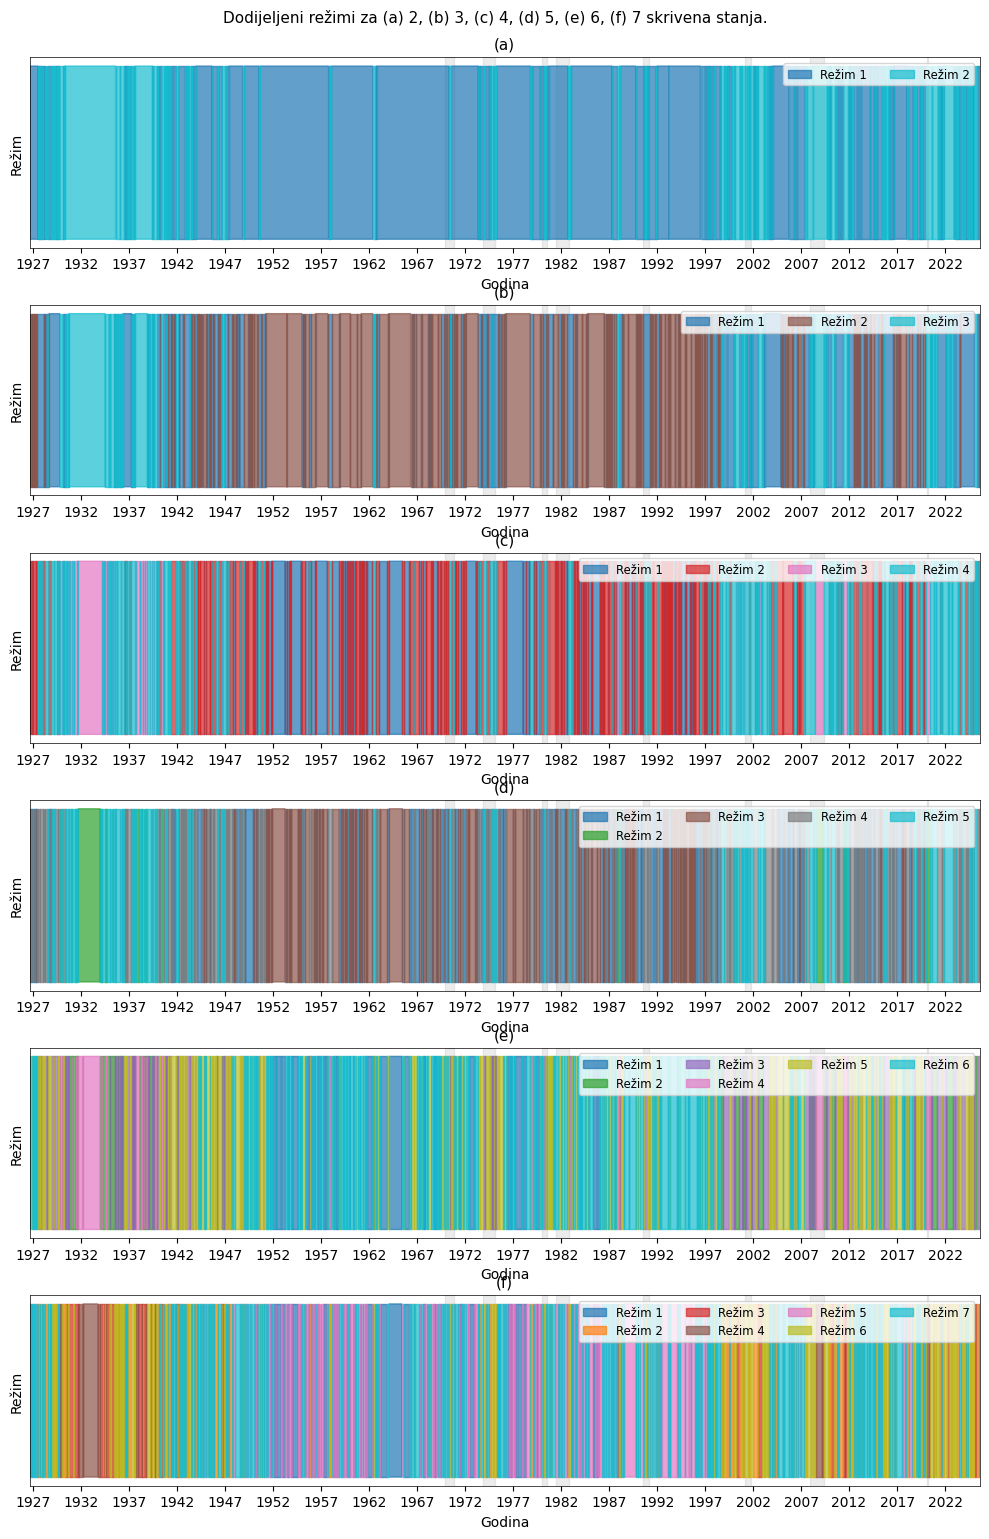

In [30]:
# Generate discrete state assignments
ns = [2, 3, 4, 5, 6, 7]
state_assignments_list = []

for n in ns:
    model = best_models[n]
    model.fit(train_latents)
    train_states = model.predict(train_latents)
    test_states = model.predict(test_latents)
    full_states = np.concatenate([train_states, test_states])
    state_assignments_list.append(full_states)

total_latent_samples = len(train_latents) + len(test_latents)

plot_regime_switches_discrete(
    data.iloc[50:50+total_latent_samples].index,
    state_assignments_list,
    fred_recessions,
    n_regimes_list=ns
)
